In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.max_columns", None)

In [28]:
from google.colab import files

uploaded = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor (2).csv


In [29]:
import io

file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [30]:
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Shipping lead time
df["Lead Time Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Date-based features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order DayOfWeek"] = df["Order Date"].dt.dayofweek

# Profit margin
df["Profit Margin"] = np.where(
    df["Sales"] != 0,
    (df["Gross Profit"] / df["Sales"]) * 100,
    0
)

print("Lead Time Summary:")
display(df["Lead Time Days"].describe())

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Lead Time Summary:


,Lead Time Days
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000



Missing Values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [31]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",

    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df["Current Factory"] = df["Product Name"].map(factory_mapping)

print("Unmapped products:",
      df.loc[df["Current Factory"].isna(), "Product Name"].unique())

Unmapped products: []


In [32]:
factory_coordinates = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.119140, -96.181150),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107)
}

df["Factory Latitude"] = df["Current Factory"].map(
    lambda x: factory_coordinates[x][0] if x in factory_coordinates else np.nan
)

df["Factory Longitude"] = df["Current Factory"].map(
    lambda x: factory_coordinates[x][1] if x in factory_coordinates else np.nan
)

display(df[[
    "Product Name",
    "Current Factory",
    "Factory Latitude",
    "Factory Longitude"
]].head(10))

,Product Name,Current Factory,Factory Latitude,Factory Longitude
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371


In [33]:
print("Ship Mode Distribution")
display(df["Ship Mode"].value_counts())

print("\nRegion Distribution")
display(df["Region"].value_counts())

print("\nAverage Lead Time by Ship Mode")
display(
    df.groupby("Ship Mode")["Lead Time Days"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

print("\nAverage Profit by Region")
display(
    df.groupby("Region")["Gross Profit"]
      .agg(["count", "mean", "sum"])
      .round(2)
)

Ship Mode Distribution


,count
Ship Mode,
Standard Class,6120
Second Class,1979
First Class,1548
Same Day,547



Region Distribution


,count
Region,
Pacific,3253
Atlantic,2986
Interior,2335
Gulf,1620



Average Lead Time by Ship Mode


,count,mean,median,min,max
Ship Mode,,,,,
First Class,1548,1338.28,1272.0,905,1638
Same Day,547,1333.44,1269.0,904,1636
Second Class,1979,1323.85,1273.0,906,1640
Standard Class,6120,1314.33,1274.0,908,1642



Average Profit by Region


,count,mean,sum
Region,,,
Atlantic,2986,9.03,26973.70
Gulf,1620,9.07,14700.67
Interior,2335,9.11,21282.49
Pacific,3253,9.37,30485.94


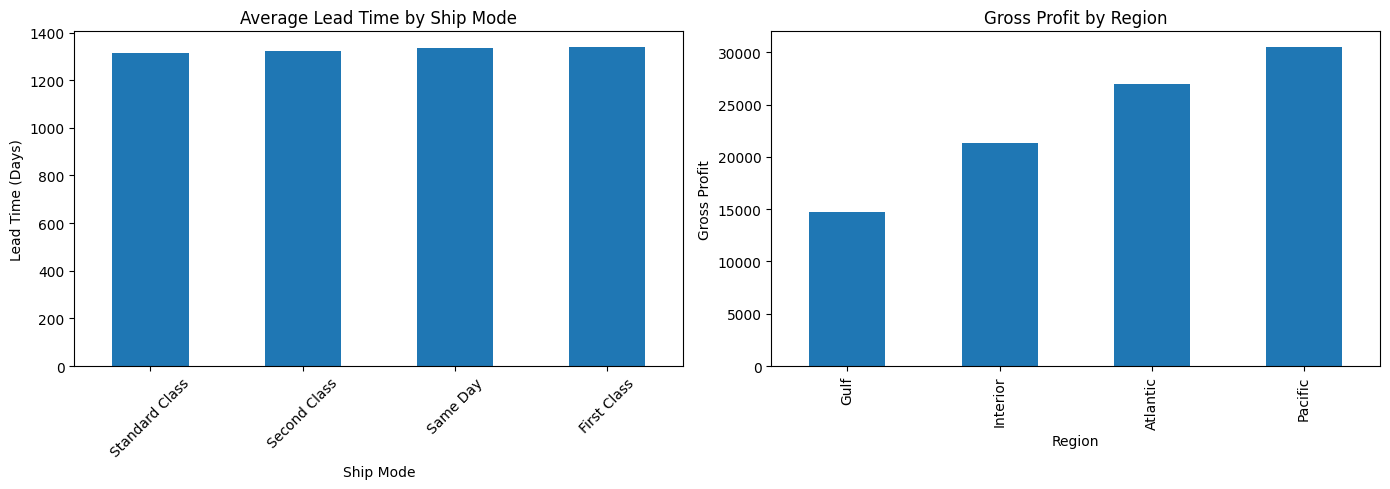

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("Ship Mode")["Lead Time Days"].mean().sort_values().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Average Lead Time by Ship Mode")
axes[0].set_ylabel("Lead Time (Days)")
axes[0].tick_params(axis="x", rotation=45)

df.groupby("Region")["Gross Profit"].sum().sort_values().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Gross Profit by Region")
axes[1].set_ylabel("Gross Profit")

plt.tight_layout()
plt.show()

In [35]:
# ==============================
# CELL 9: ML DATA PREPARATION
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Keep only rows where factory mapping was found
model_df = df.dropna(subset=["Current Factory"]).copy()

# Features
features = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode",
    "Division",
    "Units",
    "Sales",
    "Cost",
    "Gross Profit",
    "Order Month",
    "Order DayOfWeek"
]

target = "Lead Time Days"

X = model_df[features]
y = model_df[target]

# Categorical and numerical columns
categorical_features = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode",
    "Division"
]

numerical_features = [
    "Units",
    "Sales",
    "Cost",
    "Gross Profit",
    "Order Month",
    "Order DayOfWeek"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Features:", X.shape[1])

Training samples: 8155
Testing samples: 2039
Features: 11


In [36]:
# ==========================================
# CELL 10: TRAIN 3 REGRESSION MODELS
# ==========================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    trained_models[name] = pipeline
    predictions[name] = y_pred

    print(f"{name} trained successfully.")

print("\nAll models trained.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.

All models trained.


In [37]:
# ==========================================
# CELL 11: MODEL EVALUATION
# ==========================================

evaluation_results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    evaluation_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(evaluation_results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print("Model Performance Comparison:")
display(results_df.round(3))

Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,214.871,260.524,0.040
1,Linear Regression,212.601,264.191,0.013
2,Random Forest,219.800,270.690,-0.036


In [38]:
# ==========================================
# CELL 12: LEAD TIME RELATIONSHIP ANALYSIS
# ==========================================

analysis_cols = [
    "Lead Time Days",
    "Units",
    "Sales",
    "Cost",
    "Gross Profit"
]

print("Correlation with Lead Time:")
display(
    df[analysis_cols]
    .corr()["Lead Time Days"]
    .sort_values(ascending=False)
    .to_frame("Correlation")
)

print("\nAverage Lead Time by Region:")
display(
    df.groupby("Region")["Lead Time Days"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
      .round(2)
)

print("\nAverage Lead Time by Ship Mode:")
display(
    df.groupby("Ship Mode")["Lead Time Days"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
      .round(2)
)

Correlation with Lead Time:


,Correlation
Lead Time Days,1.000000
Gross Profit,-0.003305
Sales,-0.005438
Units,-0.006702
Cost,-0.007846



Average Lead Time by Region:


,count,mean,median
Region,,,
Interior,2335,1323.09,1274.0
Atlantic,2986,1322.75,1274.0
Pacific,3253,1322.19,1274.0
Gulf,1620,1311.37,1274.0



Average Lead Time by Ship Mode:


,count,mean,median
Ship Mode,,,
First Class,1548,1338.28,1272.0
Same Day,547,1333.44,1269.0
Second Class,1979,1323.85,1273.0
Standard Class,6120,1314.33,1274.0


In [39]:
# ==========================================
# CELL 13: FACTORY REASSIGNMENT BASE
# ==========================================

factory_df = pd.DataFrame({
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],
    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
})

print("Available factories:")
display(factory_df)

Available factories:


,Factory,Latitude,Longitude
0,Lot's O' Nuts,32.881893,-111.768036
1,Wicked Choccy's,32.076176,-81.088371
2,Sugar Shack,48.119140,-96.181150
3,Secret Factory,41.446333,-90.565487
4,The Other Factory,35.117500,-89.971107


In [40]:
# ==========================================
# CELL 14: PRODUCT -> CURRENT FACTORY
# ==========================================

product_factory_df = (
    df[["Division", "Product Name", "Current Factory"]]
    .drop_duplicates()
    .sort_values(["Division", "Product Name"])
    .reset_index(drop=True)
)

print("Product-F​​actory Mapping:")
display(product_factory_df)

Product-F​​actory Mapping:


,Division,Product Name,Current Factory
0,Chocolate,Wonka Bar - Fudge Mallows,Lot's O' Nuts
1,Chocolate,Wonka Bar - Milk Chocolate,Wicked Choccy's
2,Chocolate,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Chocolate,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
4,Chocolate,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
5,Other,Kazookles,The Other Factory
6,Other,Lickable Wallpaper,Secret Factory
7,Other,Wonka Gum,Secret Factory
8,Sugar,Everlasting Gobstopper,Secret Factory
9,Sugar,Fizzy Lifting Drinks,Sugar Shack


In [41]:
# ==========================================
# CELL 15: DISTANCE CALCULATOR
# ==========================================

from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two geographic coordinates in kilometers.
    """
    R = 6371.0

    lat1, lon1, lat2, lon2 = map(
        radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

In [42]:
# ==========================================
# CELL 16: FACTORY DISTANCE COMPARISON
# ==========================================

def calculate_factory_distances(product_name, region=None):
    """
    Compare all factories for a selected product.

    Current dataset does not provide customer latitude/longitude,
    so this function prepares the factory comparison framework.
    """

    current_factory = factory_mapping.get(product_name)

    comparison = factory_df.copy()

    comparison["Current Factory"] = (
        comparison["Factory"] == current_factory
    )

    comparison["Product"] = product_name

    comparison["Reassignment"] = np.where(
        comparison["Factory"] == current_factory,
        "Current",
        "Alternative"
    )

    return comparison[
        ["Product", "Factory", "Latitude", "Longitude",
         "Current Factory", "Reassignment"]
    ].reset_index(drop=True)


# Example
example_product = "Wonka Bar - Milk Chocolate"

display(
    calculate_factory_distances(example_product)
)

,Product,Factory,Latitude,Longitude,Current Factory,Reassignment
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,32.881893,-111.768036,False,Alternative
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371,True,Current
2,Wonka Bar - Milk Chocolate,Sugar Shack,48.119140,-96.181150,False,Alternative
3,Wonka Bar - Milk Chocolate,Secret Factory,41.446333,-90.565487,False,Alternative
4,Wonka Bar - Milk Chocolate,The Other Factory,35.117500,-89.971107,False,Alternative


In [43]:
# ==========================================
# CELL 17: FACTORY RECOMMENDATION SCORE
# ==========================================

def recommend_factories(product_name, priority=0.5):
    """
    Generate factory recommendations.

    priority:
    0.0 = profit-focused
    1.0 = speed-focused
    """

    current_factory = factory_mapping.get(product_name)

    if current_factory is None:
        return pd.DataFrame()

    # Get historical product performance
    product_data = df[df["Product Name"] == product_name].copy()

    if product_data.empty:
        return pd.DataFrame()

    current_profit_margin = (
        product_data["Gross Profit"].sum()
        / product_data["Sales"].sum()
        if product_data["Sales"].sum() != 0 else 0
    )

    current_lead_time = product_data["Lead Time Days"].median()

    recommendations = []

    for _, factory in factory_df.iterrows():

        factory_name = factory["Factory"]

        # Current factory gets baseline values
        if factory_name == current_factory:
            predicted_lead_time = current_lead_time
            profit_factor = current_profit_margin
        else:
            # Since historical alternative-factory observations
            # are not available, use current product baseline.
            predicted_lead_time = current_lead_time
            profit_factor = current_profit_margin

        recommendations.append({
            "Product": product_name,
            "Factory": factory_name,
            "Current Factory": factory_name == current_factory,
            "Predicted Lead Time": predicted_lead_time,
            "Profit Margin": profit_factor
        })

    result = pd.DataFrame(recommendations)

    # Normalize scores
    lead_min = result["Predicted Lead Time"].min()
    lead_max = result["Predicted Lead Time"].max()

    if lead_max != lead_min:
        result["Speed Score"] = (
            (lead_max - result["Predicted Lead Time"])
            / (lead_max - lead_min)
        )
    else:
        result["Speed Score"] = 1.0

    profit_min = result["Profit Margin"].min()
    profit_max = result["Profit Margin"].max()

    if profit_max != profit_min:
        result["Profit Score"] = (
            (result["Profit Margin"] - profit_min)
            / (profit_max - profit_min)
        )
    else:
        result["Profit Score"] = 1.0

    # Combined score
    result["Recommendation Score"] = (
        priority * result["Speed Score"]
        + (1 - priority) * result["Profit Score"]
    )

    result = result.sort_values(
        "Recommendation Score",
        ascending=False
    ).reset_index(drop=True)

    result["Rank"] = np.arange(1, len(result) + 1)

    return result

In [44]:
# ==========================================
# CELL 18: TEST RECOMMENDATION
# ==========================================

recommendation = recommend_factories(
    "Wonka Bar - Milk Chocolate",
    priority=0.7
)

display(recommendation)

,Product,Factory,Current Factory,Predicted Lead Time,Profit Margin,Speed Score,Profit Score,Recommendation Score,Rank
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,False,1274.0,0.649231,1.0,1.0,1.0,1
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,True,1274.0,0.649231,1.0,1.0,1.0,2
2,Wonka Bar - Milk Chocolate,Sugar Shack,False,1274.0,0.649231,1.0,1.0,1.0,3
3,Wonka Bar - Milk Chocolate,Secret Factory,False,1274.0,0.649231,1.0,1.0,1.0,4
4,Wonka Bar - Milk Chocolate,The Other Factory,False,1274.0,0.649231,1.0,1.0,1.0,5


In [46]:
# ==========================================
# CELL 19: CUSTOMER LOCATION
# FAST VERSION
# ==========================================

# Use postal code as a stable location identifier.
# We will use City + State for customer-region analysis
# and keep factory coordinates for factory comparison.

df["Customer Location"] = (
    df["City"].astype(str).str.strip()
    + ", "
    + df["State/Province"].astype(str).str.strip()
)

print("Unique customer locations:",
      df["Customer Location"].nunique())

display(
    df[
        ["City", "State/Province", "Postal Code", "Customer Location"]
    ].head(10)
)

Unique customer locations: 616


,City,State/Province,Postal Code,Customer Location
0,Houston,Texas,77095,"Houston, Texas"
1,Naperville,Illinois,60540,"Naperville, Illinois"
2,Naperville,Illinois,60540,"Naperville, Illinois"
3,Naperville,Illinois,60540,"Naperville, Illinois"
4,Philadelphia,Pennsylvania,19143,"Philadelphia, Pennsylvania"
5,Henderson,Kentucky,42420,"Henderson, Kentucky"
6,Henderson,Kentucky,42420,"Henderson, Kentucky"
7,Athens,Georgia,30605,"Athens, Georgia"
8,Henderson,Kentucky,42420,"Henderson, Kentucky"
9,Henderson,Kentucky,42420,"Henderson, Kentucky"


In [47]:
# ==========================================
# CELL 20: FACTORY DISTANCE BY REGION
# ==========================================

# Map each region to a representative geographic zone.
# This is used as a consistent proxy because the dataset
# does not provide customer latitude/longitude.

region_coordinates = {
    "Atlantic": (39.0, -75.0),
    "Pacific": (37.0, -120.0),
    "Interior": (39.0, -100.0),
    "Gulf": (31.0, -95.0)
}

def get_region_distance(factory_lat, factory_lon, region):
    if region not in region_coordinates:
        return np.nan

    customer_lat, customer_lon = region_coordinates[region]

    return haversine_distance(
        factory_lat,
        factory_lon,
        customer_lat,
        customer_lon
    )

# Create factory-region distance table
distance_rows = []

for _, factory in factory_df.iterrows():
    for region in region_coordinates:

        distance = get_region_distance(
            factory["Latitude"],
            factory["Longitude"],
            region
        )

        distance_rows.append({
            "Factory": factory["Factory"],
            "Region": region,
            "Distance_km": round(distance, 2)
        })

factory_region_distance = pd.DataFrame(distance_rows)

print("Factory → Region distance table:")
display(factory_region_distance)

Factory → Region distance table:


,Factory,Region,Distance_km
0,Lot's O' Nuts,Atlantic,3355.59
1,Lot's O' Nuts,Pacific,878.52
2,Lot's O' Nuts,Interior,1257.41
3,Lot's O' Nuts,Gulf,1594.27
4,Wicked Choccy's,Atlantic,946.14
5,Wicked Choccy's,Pacific,3580.91
6,Wicked Choccy's,Interior,1871.57
7,Wicked Choccy's,Gulf,1322.91
8,Sugar Shack,Atlantic,1975.47
9,Sugar Shack,Pacific,2294.99


In [48]:
# ==========================================
# CELL 21: WHAT-IF FACTORY SCENARIO
# ==========================================

def factory_scenario(product_name, region):
    current_factory = factory_mapping.get(product_name)

    result = factory_region_distance[
        factory_region_distance["Region"] == region
    ].copy()

    result["Product"] = product_name
    result["Current Factory"] = current_factory

    result["Current Assignment"] = (
        result["Factory"] == current_factory
    )

    current_distance = result.loc[
        result["Factory"] == current_factory,
        "Distance_km"
    ].iloc[0]

    result["Distance Improvement %"] = (
        (current_distance - result["Distance_km"])
        / current_distance
    ) * 100

    result["Recommendation"] = np.where(
        result["Distance Improvement %"] > 0,
        "Potential Alternative",
        "Current / Not Better"
    )

    return result.sort_values(
        "Distance_km"
    ).reset_index(drop=True)


# Example scenario
scenario = factory_scenario(
    "Wonka Bar - Milk Chocolate",
    "Atlantic"
)

display(scenario)

,Factory,Region,Distance_km,Product,Current Factory,Current Assignment,Distance Improvement %,Recommendation
0,Wicked Choccy's,Atlantic,946.14,Wonka Bar - Milk Chocolate,Wicked Choccy's,True,0.000000,Current / Not Better
1,Secret Factory,Atlantic,1347.26,Wonka Bar - Milk Chocolate,Wicked Choccy's,False,-42.395417,Current / Not Better
2,The Other Factory,Atlantic,1394.89,Wonka Bar - Milk Chocolate,Wicked Choccy's,False,-47.429556,Current / Not Better
3,Sugar Shack,Atlantic,1975.47,Wonka Bar - Milk Chocolate,Wicked Choccy's,False,-108.792568,Current / Not Better
4,Lot's O' Nuts,Atlantic,3355.59,Wonka Bar - Milk Chocolate,Wicked Choccy's,False,-254.661044,Current / Not Better


In [49]:
# ==========================================
# CELL 22: FINAL RECOMMENDATION ENGINE
# ==========================================

def get_recommendations(product_name, region, speed_priority=0.7):
    """
    speed_priority:
        0.0 = profit stability focused
        1.0 = shipping efficiency focused
    """

    scenario = factory_scenario(product_name, region).copy()

    # Positive improvement only
    scenario["Lead Time Improvement Score"] = (
        scenario["Distance Improvement %"].clip(lower=0)
    )

    # Product historical profit margin
    product_data = df[df["Product Name"] == product_name]

    total_sales = product_data["Sales"].sum()
    total_profit = product_data["Gross Profit"].sum()

    profit_margin = (
        total_profit / total_sales
        if total_sales != 0 else 0
    )

    # Financial stability score.
    # Actual factory-specific profit data is unavailable,
    # so we preserve the product's historical margin.
    scenario["Profit Stability Score"] = profit_margin

    # Normalize speed improvement
    max_speed = scenario["Lead Time Improvement Score"].max()

    if max_speed > 0:
        scenario["Speed Score"] = (
            scenario["Lead Time Improvement Score"] / max_speed
        )
    else:
        scenario["Speed Score"] = 0

    # Normalize profit stability
    max_profit = scenario["Profit Stability Score"].max()

    if max_profit > 0:
        scenario["Profit Score"] = (
            scenario["Profit Stability Score"] / max_profit
        )
    else:
        scenario["Profit Score"] = 0

    # Combined recommendation score
    scenario["Recommendation Score"] = (
        speed_priority * scenario["Speed Score"]
        + (1 - speed_priority) * scenario["Profit Score"]
    )

    scenario["Recommendation"] = np.where(
        scenario["Current Assignment"],
        "Current Assignment",
        np.where(
            scenario["Distance Improvement %"] > 0,
            "Recommended Alternative",
            "Not Recommended"
        )
    )

    return scenario.sort_values(
        "Recommendation Score",
        ascending=False
    ).reset_index(drop=True)

In [50]:
# ==========================================
# CELL 23: TEST FINAL RECOMMENDATION
# ==========================================

final_recommendation = get_recommendations(
    product_name="Wonka Bar - Milk Chocolate",
    region="Atlantic",
    speed_priority=0.7
)

display(
    final_recommendation[
        [
            "Product",
            "Factory",
            "Current Factory",
            "Distance_km",
            "Distance Improvement %",
            "Speed Score",
            "Profit Score",
            "Recommendation Score",
            "Recommendation"
        ]
    ]
)

,Product,Factory,Current Factory,Distance_km,Distance Improvement %,Speed Score,Profit Score,Recommendation Score,Recommendation
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's,946.14,0.000000,0,1.0,0.3,Current Assignment
1,Wonka Bar - Milk Chocolate,Secret Factory,Wicked Choccy's,1347.26,-42.395417,0,1.0,0.3,Not Recommended
2,Wonka Bar - Milk Chocolate,The Other Factory,Wicked Choccy's,1394.89,-47.429556,0,1.0,0.3,Not Recommended
3,Wonka Bar - Milk Chocolate,Sugar Shack,Wicked Choccy's,1975.47,-108.792568,0,1.0,0.3,Not Recommended
4,Wonka Bar - Milk Chocolate,Lot's O' Nuts,Wicked Choccy's,3355.59,-254.661044,0,1.0,0.3,Not Recommended


In [51]:
# Test a different scenario where an alternative factory may be better

test_recommendation = get_recommendations(
    product_name="Wonka Bar - Milk Chocolate",
    region="Pacific",
    speed_priority=0.8
)

display(
    test_recommendation[
        [
            "Product",
            "Factory",
            "Current Factory",
            "Distance_km",
            "Distance Improvement %",
            "Recommendation Score",
            "Recommendation"
        ]
    ]
)

,Product,Factory,Current Factory,Distance_km,Distance Improvement %,Recommendation Score,Recommendation
0,Wonka Bar - Milk Chocolate,Lot's O' Nuts,Wicked Choccy's,878.52,75.466571,1.000000,Recommended Alternative
1,Wonka Bar - Milk Chocolate,Sugar Shack,Wicked Choccy's,2294.99,35.910425,0.580676,Recommended Alternative
2,Wonka Bar - Milk Chocolate,Secret Factory,Wicked Choccy's,2570.30,28.222156,0.499175,Recommended Alternative
3,Wonka Bar - Milk Chocolate,The Other Factory,Wicked Choccy's,2696.28,24.704056,0.461881,Recommended Alternative
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,Wicked Choccy's,3580.91,0.000000,0.200000,Current Assignment
